<a href="https://colab.research.google.com/github/aashikagarg/Machine-Learning/blob/main/Customer_data(3).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving customer_churn_data.csv to customer_churn_data.csv


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_csv('customer_churn_data.csv')

# View first few rows
df.head()

# Basic info
df.info()

# Descriptive statistics
df.describe()

# Check for missing values
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       1000 non-null   int64  
 1   Age              1000 non-null   int64  
 2   Gender           1000 non-null   object 
 3   Tenure           1000 non-null   int64  
 4   MonthlyCharges   1000 non-null   float64
 5   ContractType     1000 non-null   object 
 6   InternetService  703 non-null    object 
 7   TotalCharges     1000 non-null   float64
 8   TechSupport      1000 non-null   object 
 9   Churn            1000 non-null   object 
dtypes: float64(2), int64(3), object(5)
memory usage: 78.3+ KB


,0
CustomerID,0
Age,0
Gender,0
Tenure,0
MonthlyCharges,0
ContractType,0
InternetService,297
TotalCharges,0
TechSupport,0
Churn,0


Churn         No       Yes
Gender                    
Female  0.126394  0.873606
Male    0.106061  0.893939
Churn                 No       Yes
ContractType                      
Month-to-Month  0.000000  1.000000
One-Year        0.245675  0.754325
Two-Year        0.230000  0.770000
Churn                  No       Yes
InternetService                    
DSL              0.155844  0.844156
Fiber Optic      0.174684  0.825316
Churn              No       Yes
TechSupport                    
No           0.000000  1.000000
Yes          0.231225  0.768775


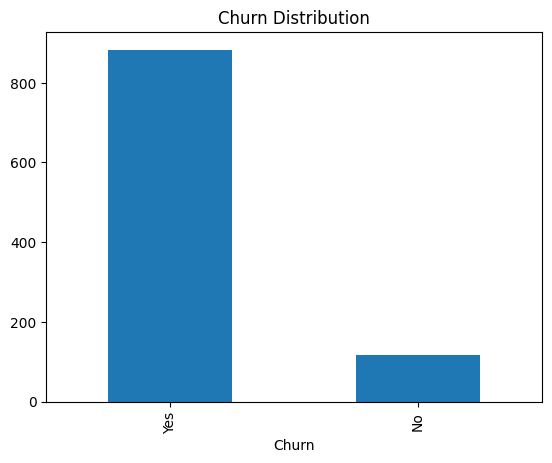

In [3]:
# Churn distribution
df['Churn'].value_counts().plot(kind='bar')
plt.title('Churn Distribution')

# Churn rate by category
for column in ['Gender', 'ContractType', 'InternetService', 'TechSupport']:
    print(pd.crosstab(df[column], df['Churn'], normalize='index'))

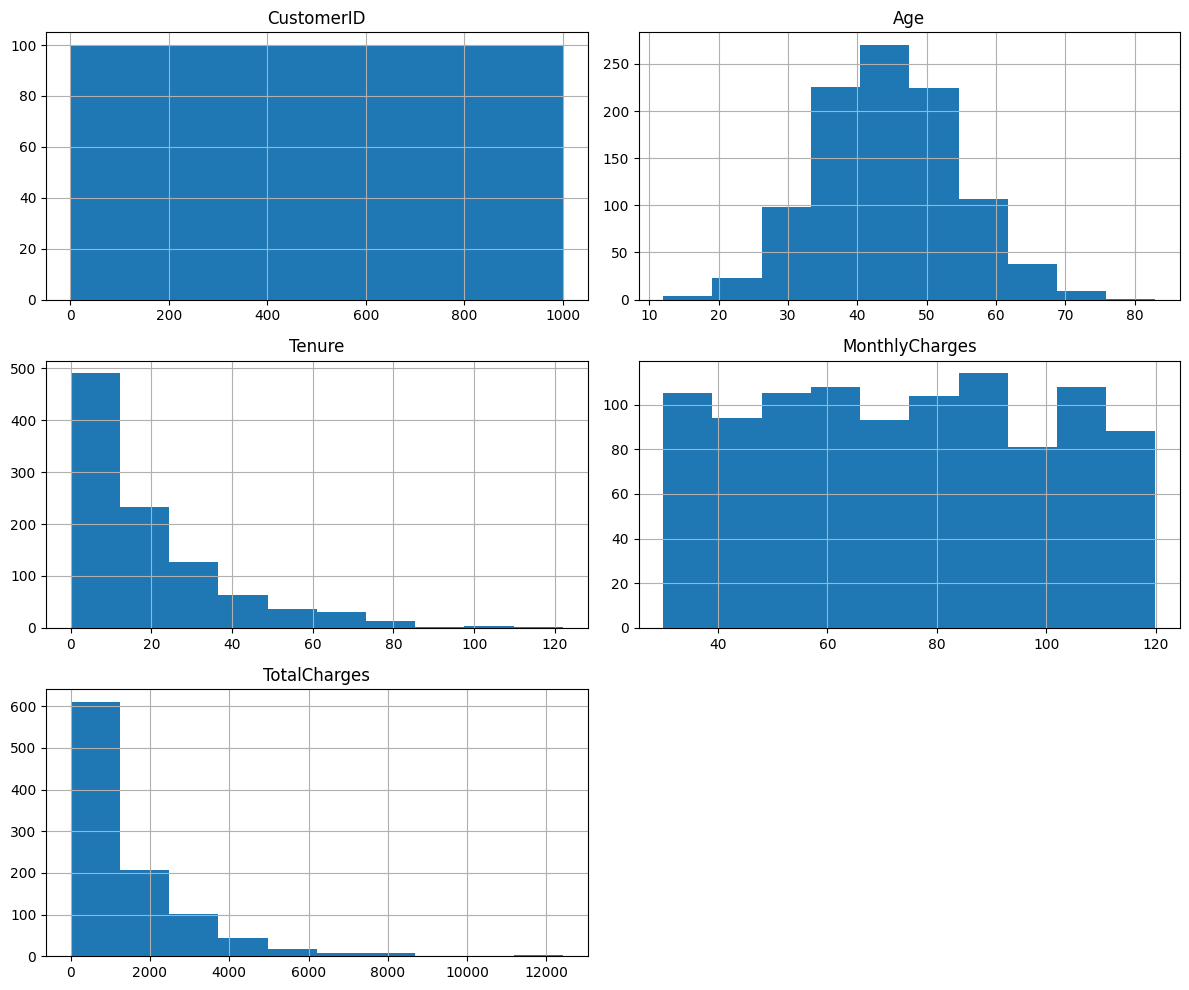

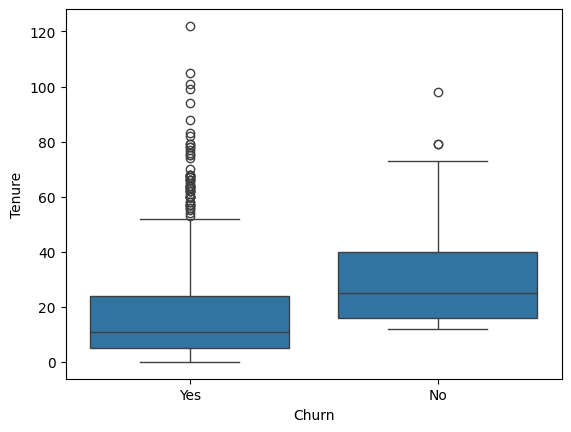

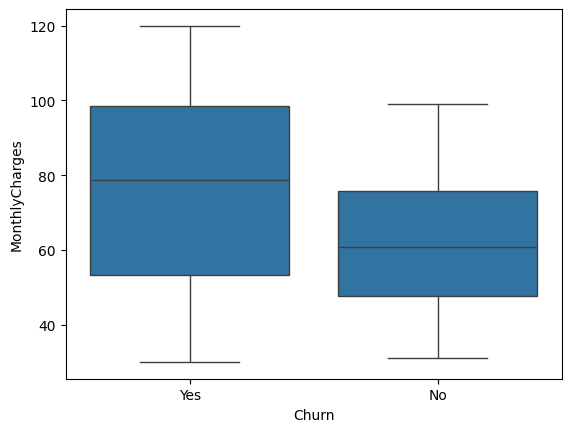

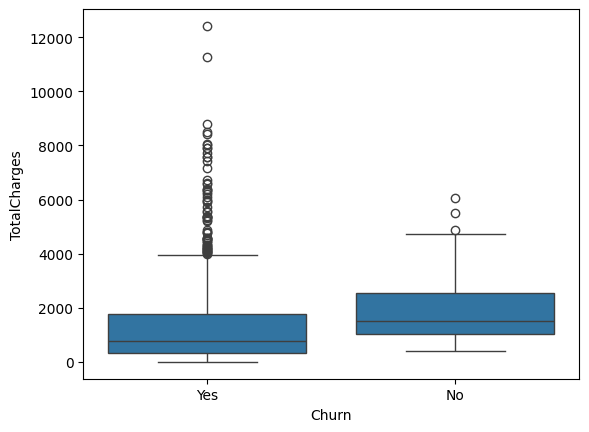

<Axes: >

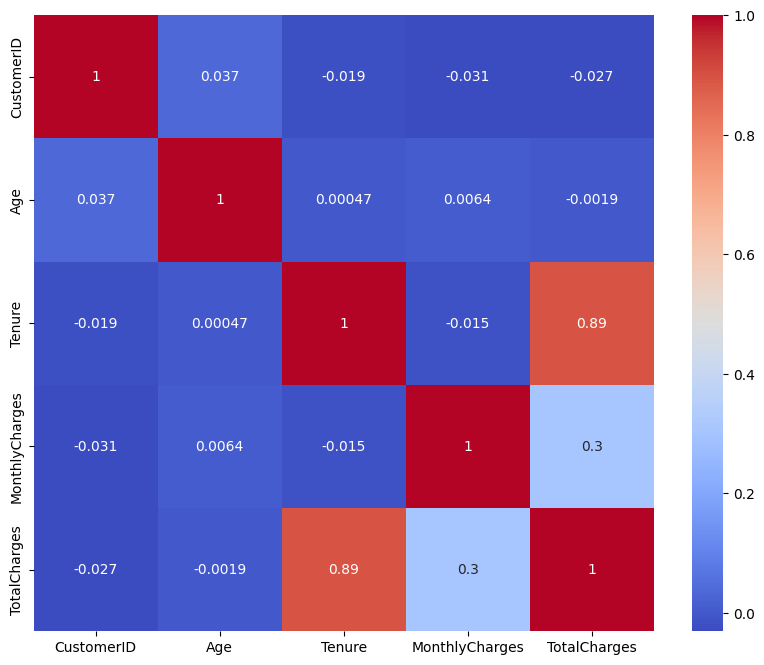

In [4]:
# Histograms for numerical features
df.hist(figsize=(12,10))
plt.tight_layout()

# Boxplots by churn status
for column in ['Age', 'Tenure', 'MonthlyCharges', 'TotalCharges']:
    sns.boxplot(x='Churn', y=column, data=df)
    plt.show()

# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

<Axes: xlabel='ContractType'>

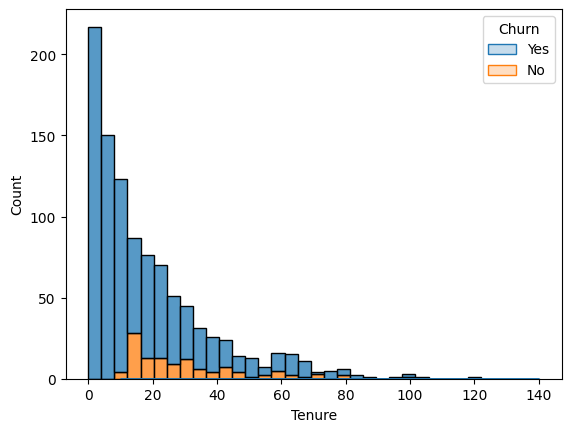

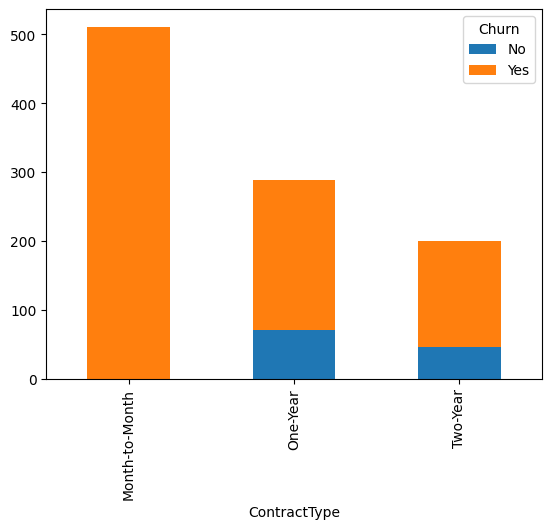

In [5]:
# Tenure vs Churn
sns.histplot(data=df, x='Tenure', hue='Churn', multiple='stack', bins=30)

# Monthly charges distribution by churn
sns.kdeplot(data=df, x='MonthlyCharges', hue='Churn', fill=True)

# Contract type impact
pd.crosstab(df['ContractType'], df['Churn']).plot(kind='bar', stacked=True)

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Encode categorical variables
le = LabelEncoder()
categorical_cols = ['Gender', 'ContractType', 'InternetService', 'TechSupport']
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# Prepare features and target
X = df.drop(['CustomerID', 'Churn'], axis=1)
y = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

<ipython-input-7-dd34d9a7414b>:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_churn = df.groupby('AgeGroup')['Churn'].value_counts(normalize=True).unstack()


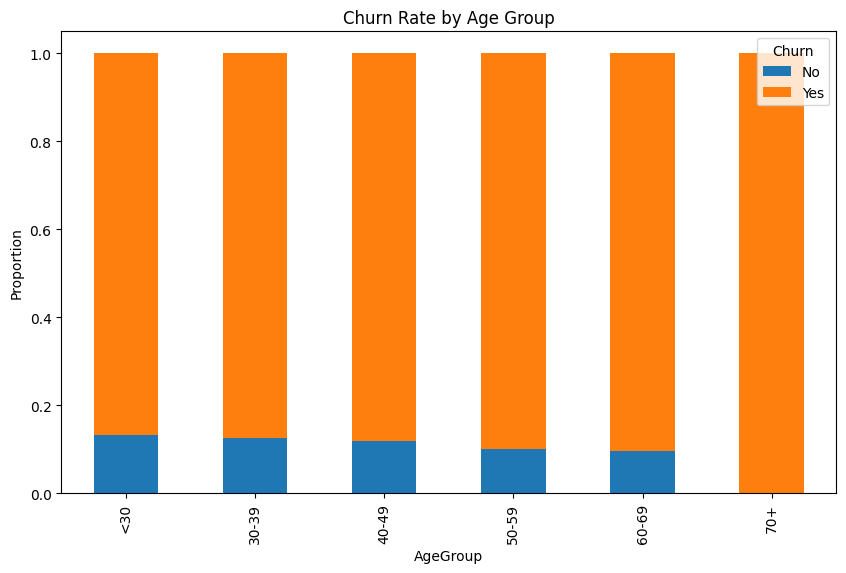

In [7]:
# Create age groups
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 30, 40, 50, 60, 70, 100],
                        labels=['<30', '30-39', '40-49', '50-59', '60-69', '70+'])

# Churn rate by age group
age_churn = df.groupby('AgeGroup')['Churn'].value_counts(normalize=True).unstack()
age_churn.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Churn Rate by Age Group')
plt.ylabel('Proportion')
plt.show()

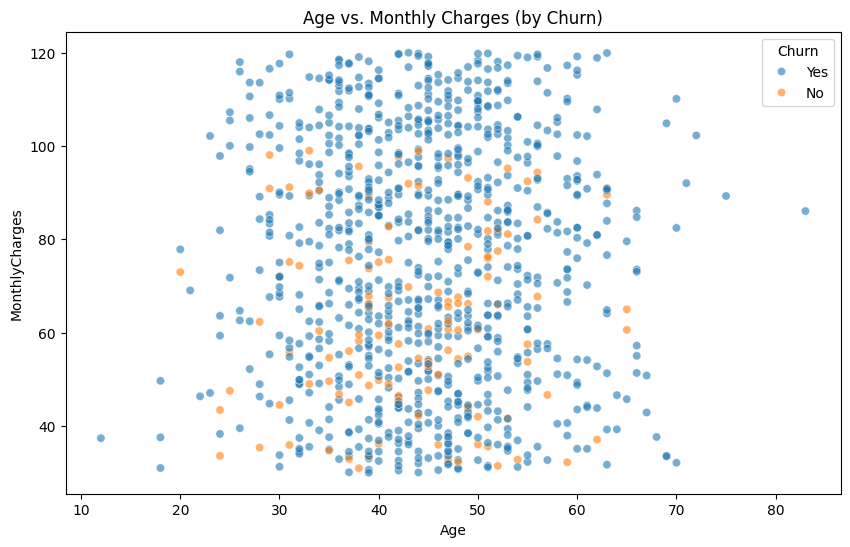

In [8]:
# Scatter plot of Age vs. MonthlyCharges (colored by Churn)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Age', y='MonthlyCharges', hue='Churn', data=df, alpha=0.6)
plt.title('Age vs. Monthly Charges (by Churn)')
plt.show()

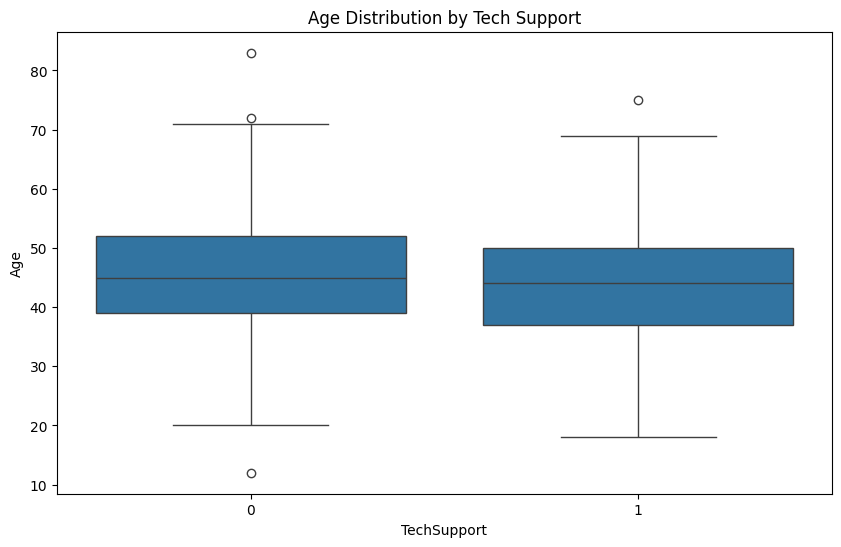

In [9]:
# Age distribution by Tech Support availability
plt.figure(figsize=(10, 6))
sns.boxplot(x='TechSupport', y='Age', data=df)
plt.title('Age Distribution by Tech Support')
plt.show()

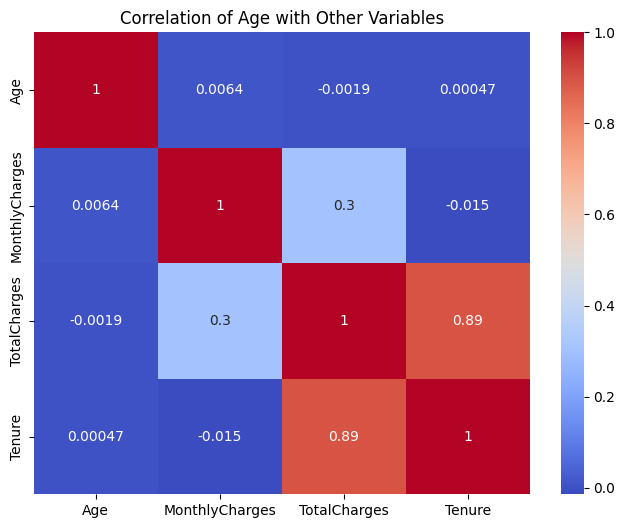

In [10]:
# Correlation of Age with other numerical variables
corr = df[['Age', 'MonthlyCharges', 'TotalCharges', 'Tenure']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation of Age with Other Variables')
plt.show()

In [11]:
df.to_csv('customer_churn_with_age_groups.csv', index=False)